In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [66]:
#read in .pt
agent_data = torch.load("reward_shaping_datasets/agent_state_action_dataset.pt")

In [48]:
import torch

# example tensor of shape [2,1000,2]
x = torch.randn(4,1000,2)

# zero‑out some entries for demonstration
x[0, [5, 10, 20]] = 0
x[1, [0, 1, 2, 999]] = 0

# build mask: True where NOT both entries == 0
# torch.all(x==0, dim=2) is True when (0,0)
mask = ~torch.all(x == 0, dim=2)       # shape [2,1000]

# now filter per batch‑element
# result is a Python list of two tensors of shape [Ni,2]
filtered = [x[b, mask[b]] for b in range(x.shape[0])]

for b, t in enumerate(filtered):
    print(f"batch {b} kept {t.shape[0]} vectors (of 1000)")


batch 0 kept 997 vectors (of 1000)
batch 1 kept 996 vectors (of 1000)
batch 2 kept 1000 vectors (of 1000)
batch 3 kept 1000 vectors (of 1000)


In [49]:
filtered

[tensor([[-0.2916, -0.8943],
         [ 1.3383,  3.0248],
         [-1.0069,  1.4472],
         ...,
         [ 0.7129,  0.3369],
         [ 0.6294, -0.4117],
         [ 0.0947,  0.1669]]),
 tensor([[-1.5164,  0.2727],
         [ 1.9590, -0.1551],
         [-0.2969, -0.8750],
         ...,
         [ 0.3007, -0.5935],
         [ 1.2861,  0.5892],
         [ 0.8849,  0.6304]]),
 tensor([[-0.7134,  1.8300],
         [ 0.3535,  1.0858],
         [ 0.5828,  0.7765],
         ...,
         [-0.1414,  0.0246],
         [ 0.6969,  0.5031],
         [-0.5113, -0.5855]]),
 tensor([[ 0.4803, -0.1642],
         [ 0.9942,  0.4790],
         [-0.1227,  1.0716],
         ...,
         [ 0.9648,  2.0063],
         [ 0.1053,  0.5839],
         [-0.8995,  0.5938]])]

In [76]:
#agent_data = agent_data[:, :, 7:]
agent_data.shape

torch.Size([4, 19010, 9])

In [117]:
# Only check columns 7:9 for zeros
mask = ~torch.all(agent_data[0, :, 7:9] == 0, dim=1)   
#now filter
filtered = [agent_data[b, mask] for b in range(agent_data.shape[0])]

In [118]:
#increase dimensions of filtered
filtered = [torch.unsqueeze(filtered[b], 0) for b in range(len(filtered))]
combined = torch.cat(filtered, dim=0)

In [130]:
combined = torch.cat([combined[:,:,-2:], combined[:,:,:-2]], dim=2)

In [132]:
combined.shape

torch.Size([4, 14287, 9])

In [134]:
torch.save(combined, "reward_shaping_datasets/agent_state_action_dataset_no_zeros.pt")

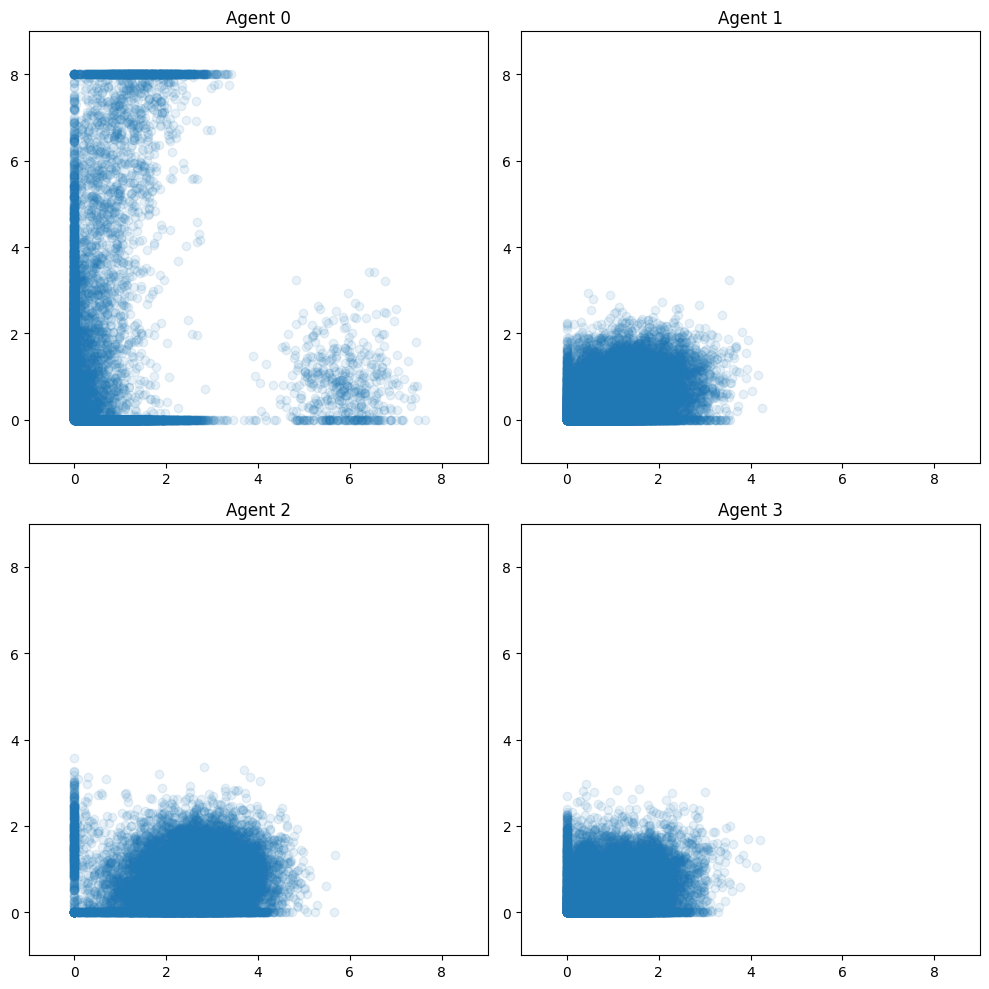

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.scatter(combined[i, :, 0], combined[i, :, 1], alpha=0.1)
    ax.set_xlim(-1, 9)  # Set x-axis limits
    ax.set_ylim(-1, 9)  # Set y-axis limits
    ax.set_title(f"Agent {i}")

plt.tight_layout()
plt.show()

In [135]:
pd.DataFrame(combined[0])

,0,1,2,3,4,5,6,7,8
0,0.000000,1.628719,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
1,0.000000,1.904664,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
2,0.000000,1.260412,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
3,0.000000,2.385301,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
4,0.000000,2.035663,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
...,...,...,...,...,...,...,...,...,...
14282,1.048078,8.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14283,2.167964,8.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14284,0.748304,8.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14285,2.128563,8.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000


In [136]:
pd.DataFrame(combined[1])

,0,1,2,3,4,5,6,7,8
0,1.530591,1.644624,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
1,1.664215,2.016987,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
2,1.480078,1.106483,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
3,2.317414,1.703259,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
4,1.350126,1.493063,15.985718,19.021986,4.683299,20.861416,0.0,9.295541,4.559101
...,...,...,...,...,...,...,...,...,...
14282,0.362307,0.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14283,0.151528,0.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14284,0.000000,0.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000
14285,0.000000,0.000000,3.965376,11.132348,8.451847,23.820114,0.0,11.036725,0.000000


In [60]:
for agent_idx in range(agent_data.shape[0]):
    agent_stats = {
        "mean": agent_data[agent_idx].mean(dim=0)[7:],
        "std": agent_data[agent_idx].std(dim=0)[7:]
    }
    print(f"Agent {agent_idx} statistics:")
    for stat_name, stat_value in agent_stats.items():
        print(f"  {stat_name}: {stat_value}")
    print()

Agent 0 statistics:
  mean: tensor([0.4861, 1.3945])
  std: tensor([1.0658, 2.2403])

Agent 1 statistics:
  mean: tensor([1.0691, 0.5263])
  std: tensor([0.7838, 0.5189])

Agent 2 statistics:
  mean: tensor([2.5353, 0.7612])
  std: tensor([0.9387, 0.6098])

Agent 3 statistics:
  mean: tensor([0.9784, 0.4351])
  std: tensor([0.7023, 0.4926])



In [61]:
from scipy.stats import wasserstein_distance

# Extract the relevant data
data1 = agent_data[0, :, 7:].numpy().flatten()
data2 = agent_data[1, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.620875316102382


In [62]:
# Extract the relevant data
data1 = agent_data[1, :, 7:].numpy().flatten()
data2 = agent_data[0, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.620875316102382


In [63]:
# Extract the relevant data
data1 = agent_data[2, :, 7:].numpy().flatten()
data2 = agent_data[0, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 1.1176765630103997


In [64]:
# Extract the relevant data
data1 = agent_data[3, :, 7:].numpy().flatten()
data2 = agent_data[2, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.9414980503865937


# NK Penalties

In [35]:
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')
ours = pd.read_csv('surrogate_plots/surrogate_nk_penalty_data_ours.csv')
nlot = pd.read_csv('surrogate_plots/surrogate_nk_penalty_data_nlot.csv')
eucl = pd.read_csv('surrogate_plots/surrogate_nk_penalty_data_eucl.csv')
eucl_w_potential = pd.read_csv('surrogate_plots/surrogate_nk_penalty_data_eucl_w_potential.csv')

In [36]:
# Calculate average absolute difference between true data and each surrogate model
diff_ours = abs(true['Average Penalty'] - ours['Average Penalty']).mean()
diff_nlot = abs(true['Average Penalty'] - nlot['Average Penalty']).mean()
diff_eucl = abs(true['Average Penalty'] - eucl['Average Penalty']).mean()
diff_eucl_w_potential = abs(true['Average Penalty'] - eucl_w_potential['Average Penalty']).mean()

# Display the results
print(f"Average difference between true and our model: {diff_ours:.6f}")
print(f"Average difference between true and NLOT model: {diff_nlot:.6f}")
print(f"Average difference between true and Euclidean model: {diff_eucl:.6f}")
print(f"Average difference between true and Euclidean w/ potential model: {diff_eucl_w_potential:.6f}")

# Find the model with the lowest average difference
models = {
    "Our model": diff_ours,
    "NLOT model": diff_nlot,
    "Euclidean model": diff_eucl,
    "Euclidean w/ potential model": diff_eucl_w_potential
}
best_model = min(models, key=models.get)
print(f"\nThe model with the lowest average difference is: {best_model} ({models[best_model]:.6f})")

Average difference between true and our model: 0.002897
Average difference between true and NLOT model: 0.007014
Average difference between true and Euclidean model: 0.002861
Average difference between true and Euclidean w/ potential model: 0.002471

The model with the lowest average difference is: Euclidean w/ potential model (0.002471)


In [14]:
true

,Lambda,Average Penalty,Standard Deviation
0,0.0,-0.065885,0.001045
1,1.0,-0.045159,0.007538
2,2.0,-0.039702,0.002144
3,3.0,-0.032469,0.001745
4,4.0,-0.029071,0.001406
5,5.0,-0.024459,0.001323
6,6.0,-0.026876,0.001246
7,7.0,-0.029040,0.001658
8,8.0,-0.022576,0.001607
9,9.0,-0.022239,0.001137
